<a href="https://colab.research.google.com/github/Roua-Elayeb/Conception-de-Robots-Intelligents-avec-NVIDIA-Jetson/blob/main/Impact%20de%20l'Augmentation%20de%20Donn%C3%A9es%20sur%20%20l'Entra%C3%AEnement%20d'un%20CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
Entraînement : (50000, 32, 32, 3)
Test : (10000, 32, 32, 3)


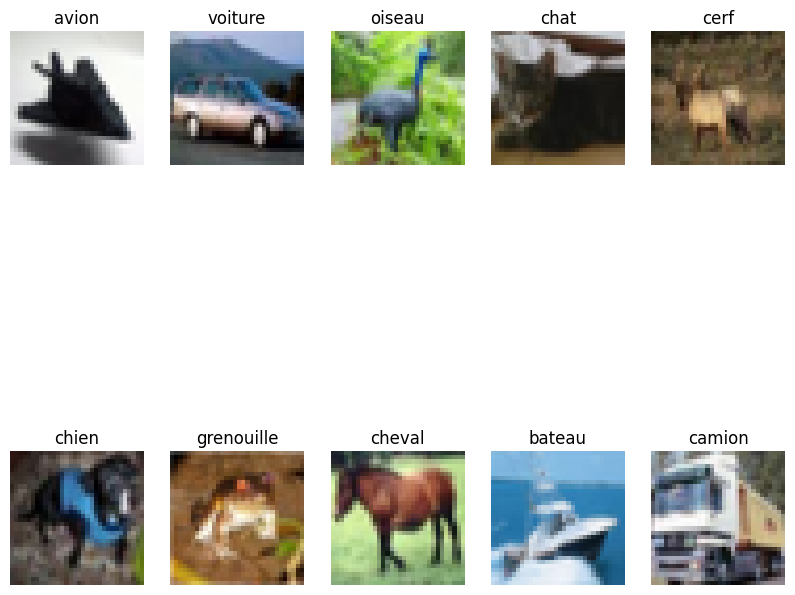

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# 2. Chargement des données
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# 3. Dimensions des tableaux
print(f"Entraînement : {x_train.shape}") # Devrait être (50000, 32, 32, 3)
print(f"Test : {x_test.shape}")

# 4. Liste des classes
class_names = ['avion', 'voiture', 'oiseau', 'chat', 'cerf', 'chien', 'grenouille', 'cheval', 'bateau', 'camion']

# 5. Affichage d'une image par classe
plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(2, 5, i+1)
    idx = np.where(y_train == i)[0][0]
    plt.imshow(x_train[idx])
    plt.title(class_names[i])
    plt.axis('off')
plt.show()

# Questions de réflexion :
# Intervalle des pixels : x_train.min() est 0, x_train.max() est 255.
# Format des étiquettes : y_train contient des entiers (0 à 9).

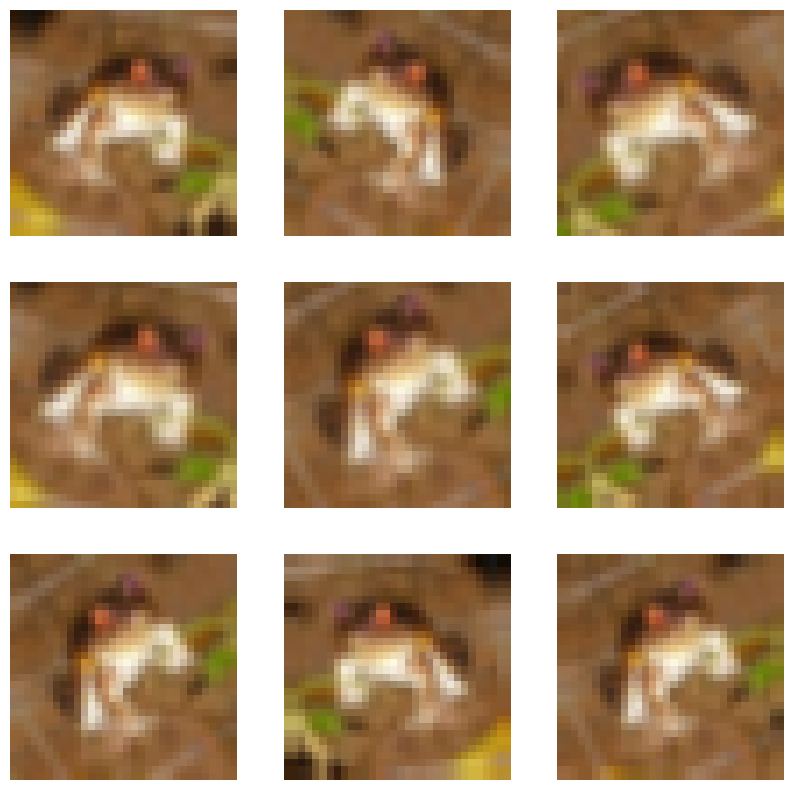

In [ ]:
# 1 & 2. Création du modèle séquentiel d'augmentation
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal"),
  tf.keras.layers.RandomRotation(0.1),
  tf.keras.layers.RandomZoom(0.1),
])

# 3. Visualisation de l'effet sur une image
plt.figure(figsize=(10, 10))
image = x_train[0]
for i in range(9):
    augmented_image = data_augmentation(tf.expand_dims(image, 0))
    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_image[0] / 255) # Division par 255 juste pour l'affichage
    plt.axis('off')

In [ ]:
# 1. Architecture de base du CNN
def create_base_cnn():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10) # 10 classes
    ])
    return model

# 2. Modèle de base (avec Rescaling)
model_base = tf.keras.Sequential([
  tf.keras.layers.Rescaling(1./255, input_shape=(32, 32, 3)),
  create_base_cnn()
])

# 2. Modèle avec Augmentation
model_aug = tf.keras.Sequential([
  data_augmentation,
  tf.keras.layers.Rescaling(1./255),
  create_base_cnn()
])

# 3. Résumé
model_base.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 10)             │       167,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 1. Compilation
model_base.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model_aug.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# 2. Expérience 1 : Sans augmentation
history_base = model_base.fit(x_train, y_train, epochs=2,
                    validation_data=(x_test, y_test))

# 3. Expérience 2 : Avec augmentation
history_aug = model_aug.fit(x_train, y_train, epochs=2,
                    validation_data=(x_test, y_test))

Epoch 1/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 44ms/step - accuracy: 0.6540 - loss: 0.9974 - val_accuracy: 0.6636 - val_loss: 0.9705
Epoch 2/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.6849 - loss: 0.9077 - val_accuracy: 0.6667 - val_loss: 0.9821
Epoch 1/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 50ms/step - accuracy: 0.4202 - loss: 1.5972 - val_accuracy: 0.5011 - val_loss: 1.3816
Epoch 2/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.5272 - loss: 1.3266 - val_accuracy: 0.5821 - val_loss: 1.1812


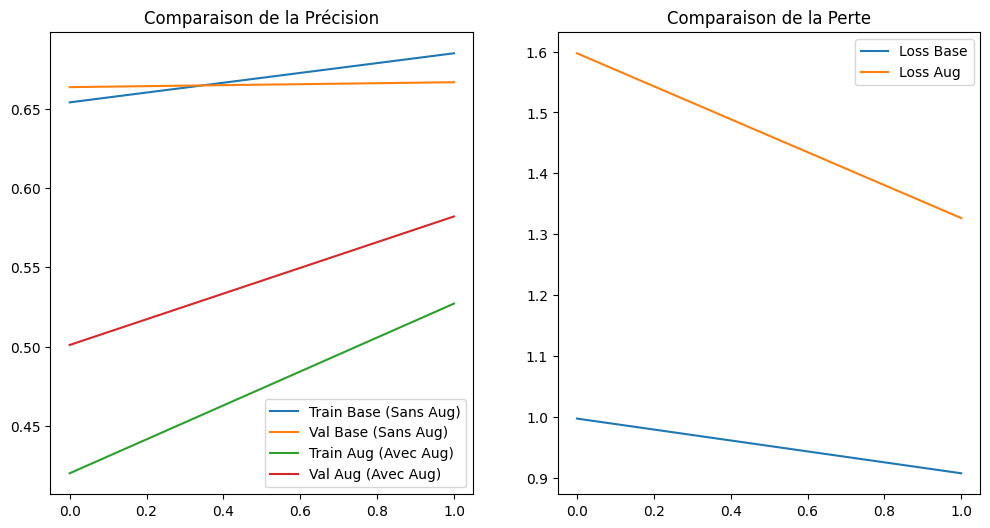

In [ ]:
acc_base = history_base.history['accuracy']
val_acc_base = history_base.history['val_accuracy']
acc_aug = history_aug.history['accuracy']
val_acc_aug = history_aug.history['val_accuracy']

epochs_range = range(len(acc_base)) # Changed from range(20)

plt.figure(figsize=(12, 6))

# Graphique de la précision
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc_base, label='Train Base (Sans Aug)')
plt.plot(epochs_range, val_acc_base, label='Val Base (Sans Aug)')
plt.plot(epochs_range, acc_aug, label='Train Aug (Avec Aug)')
plt.plot(epochs_range, val_acc_aug, label='Val Aug (Avec Aug)')
plt.title('Comparaison de la Précision')
plt.legend()

# Graphique de la perte (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_base.history['loss'], label='Loss Base')
plt.plot(epochs_range, history_aug.history['loss'], label='Loss Aug')
plt.title('Comparaison de la Perte')
plt.legend()

plt.show()

Ce TP évalue l'impact de l'**augmentation de données** sur un modèle **CNN** via le dataset **CIFAR-10**. Après l'exploration des données, un pipeline de transformations aléatoires (rotation, zoom, flip) est créé avec des couches Keras. Deux modèles sont entraînés sur 20 époques : un modèle de base et un modèle avec augmentation. La comparaison finale des courbes d'apprentissage permet d'analyser la réduction du **surapprentissage** et l'amélioration de la précision du modèle.